<a href="https://colab.research.google.com/github/abinayanand7896-cloud/Abinaya_Anand/blob/main/Mask_detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing required Libraries**

In [1]:
import numpy as np
import pandas as pd
import os
import zipfile
import cv2
import random
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import keras
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

**Dataset Extraction**

In [2]:
zip_path = "/content/face_mask_detection.zip"
extract_path = "/content/face_mask_detection"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Extraction completed.")

Extraction completed.


**Data Reading**

In [3]:
dir="/content/face_mask_detection/data"

In [4]:
classes = os.listdir(dir)
if '.DS_Store' in classes:
  classes.remove('.DS_Store')
print(classes)

['without_mask', 'with_mask']


In [5]:
data = image_dataset_from_directory(
  dir,
  image_size=(128,128),
  batch_size= 32,
  label_mode = "categorical")

Found 7553 files belonging to 2 classes.


In [6]:
len(data)

237

**Data Visualization**

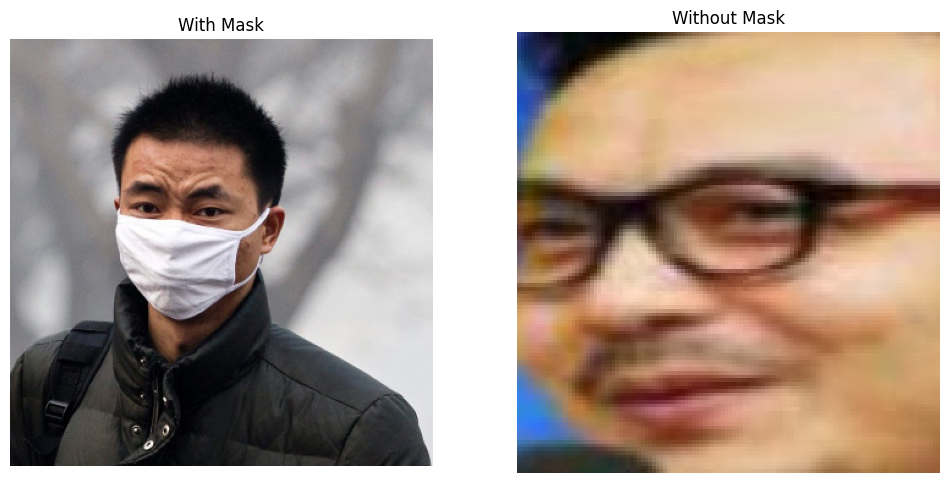

In [21]:
with_mask_path = os.path.join(dir, 'with_mask')
without_mask_path = os.path.join(dir, "without_mask")

with_mask_image = random.choice(os.listdir(with_mask_path))
without_mask_image = random.choice(os.listdir(without_mask_path))

load_with_mask = load_img(os.path.join(with_mask_path, with_mask_image))
load_without_mask = load_img(os.path.join(without_mask_path, without_mask_image))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(load_with_mask)
plt.title("With Mask")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(load_without_mask)
plt.title("Without Mask")
plt.axis('off')

plt.show()

plt.show()

**Data Preprocessing**

In [22]:
scaled_data = data.map(lambda x, y: (x/255, y))

len(scaled_data)

237

**Data Augmentation**

In [23]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

**Splitting the data**

In [24]:
total_batches = len(scaled_data)

train_size = int(0.70 * total_batches)
val_size = int(0.15 * total_batches)

train_data = scaled_data.take(train_size)
val_data = scaled_data.skip(train_size).take(val_size)
test_data = scaled_data.skip(train_size + val_size)

In [25]:
len(train_data), len(val_data), len(test_data)

(165, 35, 37)

**Model Building**

In [26]:
input_shape = (128, 128, 3)
num_classes = 2

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,426 (560.26 KB)

 Trainable params: 143,426 (560.26 KB)

 Non-trainable params: 0 (0.00 B)

**Defining Callback Funtions**

In [27]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

**Model Training**

In [28]:
batch_size = 128
epochs = 15


history = model.fit(train_data, batch_size=batch_size, epochs=epochs, validation_data=val_data, callbacks =[early_stopping, reduce_lr])

Epoch 1/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8386 - loss: 0.3671 - val_accuracy: 0.8911 - val_loss: 0.2874 - learning_rate: 0.0010
Epoch 2/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 160s 968ms/step - accuracy: 0.8958 - loss: 0.2529 - val_accuracy: 0.9179 - val_loss: 0.2159 - learning_rate: 0.0010
Epoch 3/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 161s 975ms/step - accuracy: 0.9138 - loss: 0.2160 - val_accuracy: 0.9143 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 4/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9184 - loss: 0.2055 - val_accuracy: 0.9286 - val_loss: 0.1812 - learning_rate: 0.0010
Epoch 5/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 159s 964ms/step - accuracy: 0.9248 - loss: 0.1903 - val_accuracy: 0.9277 - val_loss: 0.1914 - learning_rate: 0.0010
Epoch 6/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 158s 958ms/step - accuracy: 0.9409 - loss: 0.1562 - val_accuracy: 0.9393 - val_loss: 0.1664 - learning_rate: 0.0010
Epoch 7/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 160s 972ms/step - accuracy: 0.

**Model Evaluation**

In [29]:
score = model.evaluate(test_data, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.16383348405361176
Test accuracy: 0.9375541806221008


**Result**

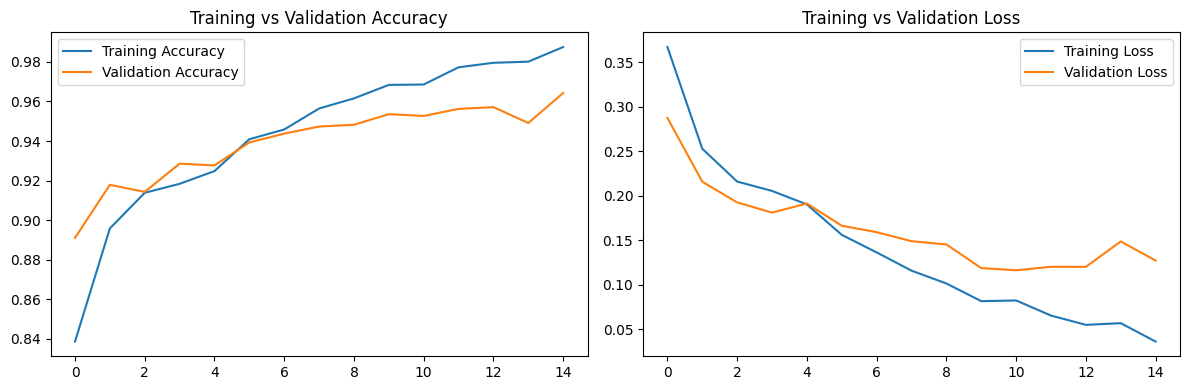

In [30]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Training Vs Validation Accuracy:** We could see that training and validation accuracy kept going up which means the model is learning well. The validation accuracy stayed close to the training accuracy. This shows the model is not overfitting and it is perform well on the new data.

**Training Vs Validation Loss:** From the result, we could see that the loss of training data kept decreasing. The validation loss goes up and down a little, but it stayed in a normal range. These small fluctation are common in real datasets. Since the validation loss doesnot increase a lot, the model is stable.

**Strengths:**

In the test dataset, the model reached a high accurracy of 93.75%, which means it has done a good job in identifying if a person is with or without mask.

The validation accuracy stayed close with the training one, so the model is not overfitting too much.

The training data loss keeps dropping which shows that the network learned the features properly.

The architecture is not very complex so the model trained quickly and doesnot require a very powerful system.

**Limitations:**

There will be dependency on the quality of input images. The model may not work well if the lightning conditions are limited.

The model is trained on the still images, so we are not sure how good it will perform in a real-time camera setup.

**Data Driven Recommendations:**

Collect more images with different lightning, angles and background so that the model can handle a wide range of real situations.